# Global Forecasting Model — Pooled Panel RF + LightGBM

**Concept:** Instead of 51 independent local models (each with only 16-18 data points),  
train one model across all 51 combos pooled together — a "Global Forecasting Model" (GFM).

**Why this matters for our data:**
- Each combo only has 16-18 quarters — too short for SARIMAX to learn robust patterns
- Combos share exposure to the same macro signals (UNRATE, seasonality, 2026 contraction)
- A pooled model learns "what does contraction look like across roles" from 51 series simultaneously

**Architecture:**
- Panel dataset: one row per (combo, quarter) ≈ 918 rows
- Features: region, role_cluster (categorical), lags (t-1, t-2, t-4), UNRATE, quarter dummies, recency metrics
- Models: Random Forest + LightGBM
- Validation: identical to NB05 — train pre-2026Q1, predict Q1 2026, compute same MAPE

**Goal:** Second opinion + feature importance tool, not a wholesale replacement of NB05.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Build Panel Dataset
#
# One row per (combo, quarter) for all 51 viable combos.
# Uses openings_adj (Q2 2026 scaled) as target.
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data')

# Load datasets
df = pd.read_pickle(os.path.join(data_dir, 'clean_42k_v1.pkl'))
mapping = pd.read_pickle(os.path.join(data_dir, 'title_to_cluster.pkl'))

# Rebuild combo keys + quarterly TS (same as NB05 Cell 1)
title_to_role = dict(zip(mapping['raw_title'], mapping['role_cluster']))
df['role_cluster'] = df['title'].map(title_to_role)
df['issue_date'] = pd.to_datetime(df['issue_date'])
df['quarter'] = df['issue_date'].dt.to_period('Q')
df['location'] = df['location'].fillna('Unknown')
df['combo_key'] = df['region'] + ' | ' + df['role_cluster']
df['openings'] = pd.to_numeric(df['openings'], errors='coerce').fillna(1)
df['fills'] = pd.to_numeric(df['fills'], errors='coerce').fillna(0)

# Build quarterly time series
ts_data = (
    df.groupby(['combo_key', 'region', 'role_cluster', 'quarter'])
    .agg(openings=('openings', 'sum'), fills=('fills', 'sum'), record_count=('title', 'count'))
    .reset_index()
)

# Identify viable combos (same logic as NB05)
train_start = pd.Period('2022Q1', freq='Q')
train_end = pd.Period('2025Q4', freq='Q')
train_quarters = sorted([q for q in ts_data['quarter'].unique() if train_start <= q <= train_end])

ts_train = ts_data[ts_data['quarter'].isin(train_quarters)]
combo_avg = ts_train.groupby('combo_key')['record_count'].mean()
viable_combos = combo_avg[combo_avg >= 10].index.tolist()

# Tier classification (for reporting)
tier_map = {combo: ('Tier 1' if combo_avg[combo] >= 30 else 'Tier 2') for combo in viable_combos}

# Q2 2026 adjustment
Q2_2026_SCALE = 1.37
ts_data['openings_adj'] = ts_data['openings'].astype(float)
mask_2026q2 = (ts_data['quarter'] == pd.Period('2026Q2', freq='Q'))
ts_data.loc[mask_2026q2, 'openings_adj'] = ts_data.loc[mask_2026q2, 'openings'].astype(float) * Q2_2026_SCALE

# UNRATE
unrate = pd.read_csv(os.path.join(data_dir, 'UNRATE.csv'))
unrate['observation_date'] = pd.to_datetime(unrate['observation_date'])
unrate['UNRATE'] = pd.to_numeric(unrate['UNRATE'], errors='coerce')
unrate = unrate.dropna(subset=['UNRATE'])
unrate['quarter'] = unrate['observation_date'].dt.to_period('Q')
unrate_qtr = unrate.groupby('quarter')['UNRATE'].mean().reset_index()
unrate_qtr.columns = ['quarter', 'unrate']

# Extrapolate UNRATE for Q3/Q4 2026
latest_unrate = unrate_qtr['unrate'].iloc[-1]
for fq in [pd.Period('2026Q3', freq='Q'), pd.Period('2026Q4', freq='Q')]:
    if fq not in unrate_qtr['quarter'].values:
        unrate_qtr = pd.concat([unrate_qtr, pd.DataFrame({'quarter': [fq], 'unrate': [latest_unrate]})],
                               ignore_index=True)

# ── Build panel: filter to viable combos, all available quarters ──
panel = ts_data[ts_data['combo_key'].isin(viable_combos)].copy()
panel = panel.merge(unrate_qtr, on='quarter', how='left')
panel['unrate'] = panel['unrate'].ffill().bfill()

# Quarter features
panel['q_num'] = panel['quarter'].apply(lambda x: x.quarter)
panel['year'] = panel['quarter'].apply(lambda x: x.year)
for q in [1, 2, 3]:  # Q4 is reference
    panel[f'Q{q}'] = (panel['q_num'] == q).astype(int)

# Sort for lag computation
panel = panel.sort_values(['combo_key', 'quarter']).reset_index(drop=True)

print(f"Panel dataset: {len(panel)} rows")
print(f"Combos: {panel['combo_key'].nunique()}")
print(f"Quarters: {panel['quarter'].min()} → {panel['quarter'].max()}")
print(f"Quarters per combo: {panel.groupby('combo_key')['quarter'].count().describe()[['min', 'max', 'mean']].to_dict()}")

Panel dataset: 1246 rows
Combos: 51
Quarters: 2017Q1 → 2026Q2
Quarters per combo: {'min': 12.0, 'max': 37.0, 'mean': 24.431372549019606}


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Feature Engineering
#
# Dynamic features: lagged openings (t-1, t-2, t-4), fills_lag1,
#   rolling mean (4Q), YoY change, trend slope.
# Static features: region, role_cluster → encoded.
# ═══════════════════════════════════════════════════════════════
from sklearn.preprocessing import LabelEncoder

# ── Lag features (within each combo) ──
for lag in [1, 2, 4]:
    panel[f'openings_lag{lag}'] = panel.groupby('combo_key')['openings_adj'].shift(lag)

# Fills lag-1
panel['fills_lag1'] = panel.groupby('combo_key')['fills'].shift(1)

# Rolling 4-quarter mean (lookback, not including current)
panel['rolling_4q_mean'] = panel.groupby('combo_key')['openings_adj'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=2).mean()
)

# YoY change: openings(t-4) vs openings(t) — use lag4 for this
panel['yoy_change'] = (panel['openings_adj'] - panel['openings_lag4']) / panel['openings_lag4'].clip(lower=1)
# Shift YoY so it's "last known YoY" (not leaking current quarter)
panel['yoy_change_lag1'] = panel.groupby('combo_key')['yoy_change'].shift(1)

# Trend: linear slope over last 4 quarters
def rolling_slope(s, window=4):
    """Compute rolling OLS slope over `window` periods."""
    slopes = []
    for i in range(len(s)):
        if i < window:
            slopes.append(np.nan)
        else:
            y = s.iloc[i-window:i].values
            x = np.arange(window)
            if np.std(y) == 0:
                slopes.append(0.0)
            else:
                slope = np.polyfit(x, y, 1)[0]
                slopes.append(slope)
    return pd.Series(slopes, index=s.index)

panel['trend_slope'] = panel.groupby('combo_key')['openings_adj'].transform(rolling_slope)

# ── Static features: encode region + role_cluster ──
le_region = LabelEncoder()
le_role = LabelEncoder()
panel['region_enc'] = le_region.fit_transform(panel['region'])
panel['role_enc'] = le_role.fit_transform(panel['role_cluster'])

# ── Combo-level size feature (avg volume — helps RF distinguish high/low vol combos) ──
combo_vol = panel[panel['quarter'] <= pd.Period('2025Q4', freq='Q')].groupby('combo_key')['openings_adj'].mean()
panel['combo_avg_vol'] = panel['combo_key'].map(combo_vol)

# ── Define feature set ──
feature_cols = [
    'unrate', 'Q1', 'Q2', 'Q3',               # macro + seasonality
    'openings_lag1', 'openings_lag2', 'openings_lag4',  # autoregressive
    'fills_lag1',                               # leading indicator
    'rolling_4q_mean',                          # smoothed level
    'yoy_change_lag1',                          # momentum
    'trend_slope',                              # direction
    'region_enc', 'role_enc',                   # static identity
    'combo_avg_vol',                            # scale context
]

target_col = 'openings_adj'

print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Target: {target_col}")
print(f"\nPanel shape before dropna: {panel.shape}")

# Drop rows where lags aren't available (first few quarters per combo)
panel_clean = panel.dropna(subset=feature_cols + [target_col]).copy()
print(f"Panel shape after dropna:  {panel_clean.shape} (lost {len(panel) - len(panel_clean)} rows from early quarters)")
print(f"Quarters remaining: {panel_clean['quarter'].min()} → {panel_clean['quarter'].max()}")
print(f"Combos remaining: {panel_clean['combo_key'].nunique()}")

Features (14): ['unrate', 'Q1', 'Q2', 'Q3', 'openings_lag1', 'openings_lag2', 'openings_lag4', 'fills_lag1', 'rolling_4q_mean', 'yoy_change_lag1', 'trend_slope', 'region_enc', 'role_enc', 'combo_avg_vol']
Target: openings_adj

Panel shape before dropna: (1246, 25)
Panel shape after dropna:  (991, 25) (lost 255 rows from early quarters)
Quarters remaining: 2018Q2 → 2026Q2
Combos remaining: 51


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — Random Forest: Train + Validate (Q1 2026 holdout)
#
# Time-based split: train on everything before 2026Q1,
# predict 2026Q1, compute identical MAPE to NB05.
# ═══════════════════════════════════════════════════════════════
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# ── Time-based split ──
val_quarter = pd.Period('2026Q1', freq='Q')
q2_2026 = pd.Period('2026Q2', freq='Q')

train_mask = panel_clean['quarter'] < val_quarter
val_mask = panel_clean['quarter'] == val_quarter

X_train = panel_clean.loc[train_mask, feature_cols].values
y_train = panel_clean.loc[train_mask, target_col].values
X_val = panel_clean.loc[val_mask, feature_cols].values
y_val = panel_clean.loc[val_mask, target_col].values
val_combos = panel_clean.loc[val_mask, 'combo_key'].values

print(f"Train: {X_train.shape[0]} rows ({panel_clean.loc[train_mask, 'quarter'].min()} → {panel_clean.loc[train_mask, 'quarter'].max()})")
print(f"Val:   {X_val.shape[0]} rows (Q1 2026, {len(val_combos)} combos)")

# ── Random Forest ──
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

# ── Predict Q1 2026 ──
rf_preds = rf.predict(X_val)
rf_preds = np.maximum(rf_preds, 0)  # no negatives

# ── Compute MAPE (identical to NB05 baseline) ──
rf_mape_per_combo = np.abs(rf_preds - y_val) / np.maximum(y_val, 1) * 100
rf_median_mape = np.median(rf_mape_per_combo)
rf_mean_mape = np.mean(rf_mape_per_combo)
rf_mae = mean_absolute_error(y_val, rf_preds)
rf_within_20 = (rf_mape_per_combo <= 20).mean() * 100
rf_within_30 = (rf_mape_per_combo <= 30).mean() * 100

print(f"\n{'═'*70}")
print(f"RANDOM FOREST — Q1 2026 VALIDATION")
print(f"{'═'*70}")
print(f"\n  Median MAPE: {rf_median_mape:.1f}%")
print(f"  Mean MAPE:   {rf_mean_mape:.1f}%")
print(f"  Median MAE:  {np.median(np.abs(rf_preds - y_val)):.1f} openings")
print(f"  Within ±20%: {rf_within_20:.1f}% of predictions")
print(f"  Within ±30%: {rf_within_30:.1f}% of predictions")

# ── Comparison to NB05 baseline ──
nb05_q1_mape = 41.8  # frozen from NB05 Cell 9
improvement = nb05_q1_mape - rf_median_mape
print(f"\n── vs NB05 Baseline (Q1 2026): ──")
print(f"  NB05 SARIMAX/ExpSmooth: {nb05_q1_mape:.1f}% median MAPE")
print(f"  RF Global Model:        {rf_median_mape:.1f}% median MAPE")
print(f"  Δ: {improvement:+.1f} pp {'(RF wins)' if improvement > 0 else '(SARIMAX wins)'}")

# ── Per-combo comparison ──
rf_val_df = pd.DataFrame({
    'combo_key': val_combos,
    'actual': y_val,
    'rf_pred': rf_preds,
    'rf_mape': rf_mape_per_combo,
    'tier': [tier_map.get(c, '?') for c in val_combos],
})

print(f"\n── By Tier: ──")
for tier in ['Tier 1', 'Tier 2']:
    t = rf_val_df[rf_val_df['tier'] == tier]
    if len(t) > 0:
        print(f"  {tier}: median MAPE={t['rf_mape'].median():.1f}%, within ±20%: {(t['rf_mape'] <= 20).mean()*100:.0f}%")

# Top 5 best / worst
print(f"\n── Top 5 best (RF): ──")
for _, r in rf_val_df.nsmallest(5, 'rf_mape').iterrows():
    print(f"  {r['combo_key'][:40]:<42} MAPE={r['rf_mape']:>5.1f}%  (actual={r['actual']:.0f}, pred={r['rf_pred']:.0f})")

print(f"\n── Top 5 worst (RF): ──")
for _, r in rf_val_df.nlargest(5, 'rf_mape').iterrows():
    print(f"  {r['combo_key'][:40]:<42} MAPE={r['rf_mape']:>5.1f}%  (actual={r['actual']:.0f}, pred={r['rf_pred']:.0f})")

Train: 896 rows (2018Q2 → 2025Q4)
Val:   49 rows (Q1 2026, 49 combos)

══════════════════════════════════════════════════════════════════════
RANDOM FOREST — Q1 2026 VALIDATION
══════════════════════════════════════════════════════════════════════

  Median MAPE: 22.9%
  Mean MAPE:   72.3%
  Median MAE:  5.5 openings
  Within ±20%: 42.9% of predictions
  Within ±30%: 53.1% of predictions

── vs NB05 Baseline (Q1 2026): ──
  NB05 SARIMAX/ExpSmooth: 41.8% median MAPE
  RF Global Model:        22.9% median MAPE
  Δ: +18.9 pp (RF wins)

── By Tier: ──
  Tier 1: median MAPE=14.5%, within ±20%: 62%
  Tier 2: median MAPE=38.4%, within ±20%: 22%

── Top 5 best (RF): ──
  US | Software Engineer                     MAPE=  0.3%  (actual=121, pred=121)
  US | Marketing Manager                     MAPE=  0.9%  (actual=26, pred=26)
  US | Business Analyst                      MAPE=  1.0%  (actual=41, pred=41)
  US | Project Manager                       MAPE=  1.3%  (actual=58, pred=57)
  US | Finan

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — LightGBM (GBDT — often outperforms RF on tabular)
#
# Same split + same MAPE calculation.
# ═══════════════════════════════════════════════════════════════
try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("⚠️  LightGBM not installed. Run: pip install lightgbm")
    print("   Skipping LGBM — RF results above still valid.")

if HAS_LGBM:
    lgb_model = lgb.LGBMRegressor(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1,
    )
    lgb_model.fit(X_train, y_train)

    # Predict Q1 2026
    lgb_preds = lgb_model.predict(X_val)
    lgb_preds = np.maximum(lgb_preds, 0)

    # MAPE
    lgb_mape_per_combo = np.abs(lgb_preds - y_val) / np.maximum(y_val, 1) * 100
    lgb_median_mape = np.median(lgb_mape_per_combo)
    lgb_within_20 = (lgb_mape_per_combo <= 20).mean() * 100
    lgb_within_30 = (lgb_mape_per_combo <= 30).mean() * 100

    print(f"{'═'*70}")
    print(f"LIGHTGBM — Q1 2026 VALIDATION")
    print(f"{'═'*70}")
    print(f"\n  Median MAPE: {lgb_median_mape:.1f}%")
    print(f"  Mean MAPE:   {np.mean(lgb_mape_per_combo):.1f}%")
    print(f"  Median MAE:  {np.median(np.abs(lgb_preds - y_val)):.1f} openings")
    print(f"  Within ±20%: {lgb_within_20:.1f}% of predictions")
    print(f"  Within ±30%: {lgb_within_30:.1f}% of predictions")

    # ── Three-way comparison ──
    print(f"\n{'═'*70}")
    print(f"THREE-WAY COMPARISON — Q1 2026 HOLDOUT")
    print(f"{'═'*70}")
    print(f"\n  {'Model':<30} {'Median MAPE':<15} {'Within ±20%':<15} {'Within ±30%'}")
    print(f"  {'─'*70}")
    print(f"  {'NB05 SARIMAX/ExpSmooth':<30} {nb05_q1_mape:>8.1f}%      {'18%':>8}        {'31%':>8}")
    print(f"  {'Random Forest (global)':<30} {rf_median_mape:>8.1f}%      {rf_within_20:>7.0f}%        {rf_within_30:>7.0f}%")
    print(f"  {'LightGBM (global)':<30} {lgb_median_mape:>8.1f}%      {lgb_within_20:>7.0f}%        {lgb_within_30:>7.0f}%")

    best_model_name = 'LightGBM' if lgb_median_mape < rf_median_mape else 'Random Forest'
    best_mape = min(lgb_median_mape, rf_median_mape)
    print(f"\n  → Best global model: {best_model_name} ({best_mape:.1f}% median MAPE)")
    print(f"  → vs NB05 baseline: {nb05_q1_mape - best_mape:+.1f} pp")
else:
    best_model_name = 'Random Forest'
    best_mape = rf_median_mape
    lgb_preds = None
    lgb_mape_per_combo = None

══════════════════════════════════════════════════════════════════════
LIGHTGBM — Q1 2026 VALIDATION
══════════════════════════════════════════════════════════════════════

  Median MAPE: 27.1%
  Mean MAPE:   74.1%
  Median MAE:  9.1 openings
  Within ±20%: 36.7% of predictions
  Within ±30%: 53.1% of predictions

══════════════════════════════════════════════════════════════════════
THREE-WAY COMPARISON — Q1 2026 HOLDOUT
══════════════════════════════════════════════════════════════════════

  Model                          Median MAPE     Within ±20%     Within ±30%
  ──────────────────────────────────────────────────────────────────────
  NB05 SARIMAX/ExpSmooth             41.8%           18%             31%
  Random Forest (global)             22.9%           43%             53%
  LightGBM (global)                  27.1%           37%             53%

  → Best global model: Random Forest (22.9% median MAPE)
  → vs NB05 baseline: +18.9 pp


══════════════════════════════════════════════════════════════════════
FEATURE IMPORTANCE — Random Forest
══════════════════════════════════════════════════════════════════════

Feature                   Importance   Interpretation
──────────────────────────────────────────────────────────────────────
  openings_lag1              0.246      Last quarter's demand (momentum)
  rolling_4q_mean            0.168      Smoothed demand level
  openings_lag2              0.153      2 quarters ago (persistence)
  combo_avg_vol              0.102      Role size (high-vol vs low-vol)
  fills_lag1                 0.091      Hiring activity → future demand signal
  openings_lag4              0.065      Same quarter last year (seasonality proxy)
  unrate                     0.062      Macro environment (unemployment)
  trend_slope                0.058      Recent trajectory direction
  yoy_change_lag1            0.027      Year-over-year momentum
  role_enc                   0.013      Role cluster i

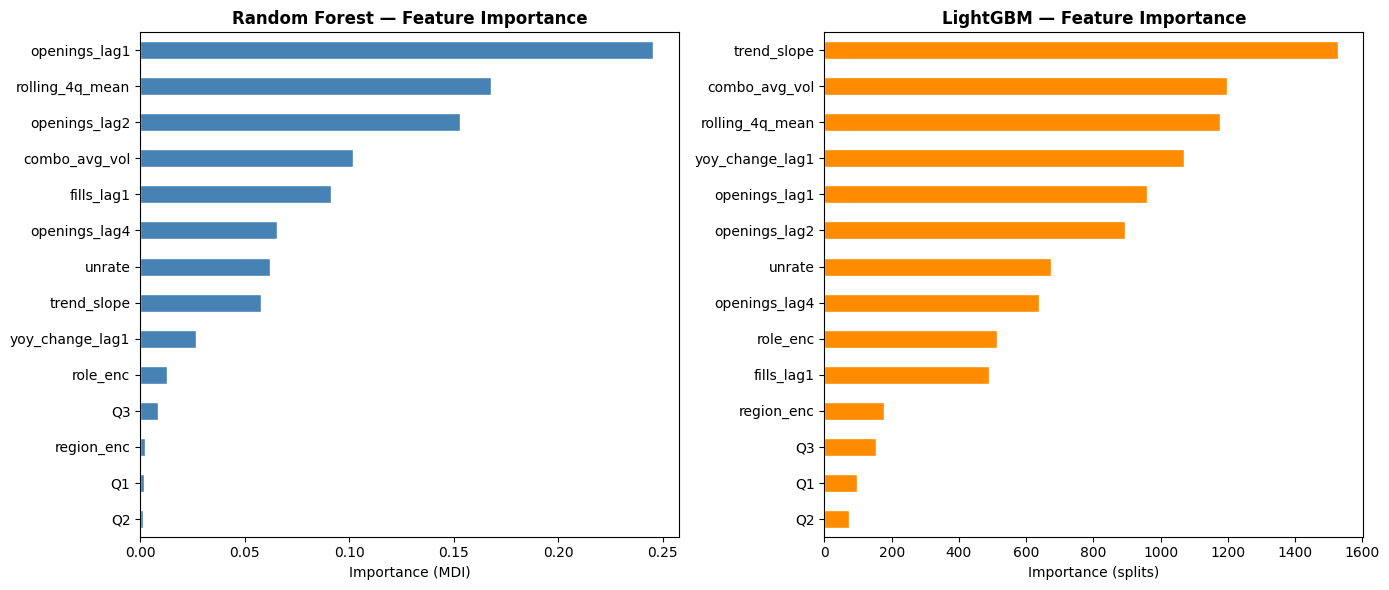


══════════════════════════════════════════════════════════════════════
KEY INSIGHTS
══════════════════════════════════════════════════════════════════════

  Top 3 drivers: openings_lag1, rolling_4q_mean, openings_lag2
  UNRATE importance: 0.062 — significant
  Region vs Role: region=0.002, role=0.013
  Autoregressive total (lag1+lag2+rolling): 0.567 — demand is strongly self-predicting


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — Feature Importance Analysis
#
# This is the "understand it better" cell — what's actually
# driving demand across the portfolio?
# ═══════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

# ── RF Feature Importance (MDI — mean decrease impurity) ──
rf_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("═"*70)
print("FEATURE IMPORTANCE — Random Forest")
print("═"*70)
print(f"\n{'Feature':<25} {'Importance':<12} {'Interpretation'}")
print("─"*70)
interpretations = {
    'openings_lag1': 'Last quarter\'s demand (momentum)',
    'openings_lag2': '2 quarters ago (persistence)',
    'openings_lag4': 'Same quarter last year (seasonality proxy)',
    'rolling_4q_mean': 'Smoothed demand level',
    'fills_lag1': 'Hiring activity → future demand signal',
    'unrate': 'Macro environment (unemployment)',
    'combo_avg_vol': 'Role size (high-vol vs low-vol)',
    'trend_slope': 'Recent trajectory direction',
    'yoy_change_lag1': 'Year-over-year momentum',
    'region_enc': 'Geographic region (US vs IN)',
    'role_enc': 'Role cluster identity',
    'Q1': 'Q1 seasonality', 'Q2': 'Q2 seasonality', 'Q3': 'Q3 seasonality',
}
for feat, imp in rf_importances.items():
    interp = interpretations.get(feat, '')
    print(f"  {feat:<23} {imp:>8.3f}      {interp}")

# ── LightGBM importance (if available) ──
if HAS_LGBM:
    lgb_importances = pd.Series(lgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    print(f"\n\n{'═'*70}")
    print("FEATURE IMPORTANCE — LightGBM (split-based)")
    print(f"{'═'*70}")
    for feat, imp in lgb_importances.items():
        interp = interpretations.get(feat, '')
        print(f"  {feat:<23} {imp:>8.0f}      {interp}")

# ── Visualization ──
fig, axes = plt.subplots(1, 2 if HAS_LGBM else 1, figsize=(14 if HAS_LGBM else 8, 6))
if not HAS_LGBM:
    axes = [axes]

ax = axes[0]
rf_importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Importance (MDI)')
ax.set_title('Random Forest — Feature Importance', fontweight='bold')
ax.invert_yaxis()

if HAS_LGBM:
    ax = axes[1]
    lgb_importances.plot(kind='barh', ax=ax, color='darkorange', edgecolor='white')
    ax.set_xlabel('Importance (splits)')
    ax.set_title('LightGBM — Feature Importance', fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

# ── Key insights ──
print(f"\n{'═'*70}")
print("KEY INSIGHTS")
print(f"{'═'*70}")
top3 = rf_importances.head(3).index.tolist()
print(f"\n  Top 3 drivers: {', '.join(top3)}")
print(f"  UNRATE importance: {rf_importances.get('unrate', 0):.3f} — {'significant' if rf_importances.get('unrate', 0) > 0.05 else 'modest/low'}")
print(f"  Region vs Role: region={rf_importances.get('region_enc', 0):.3f}, role={rf_importances.get('role_enc', 0):.3f}")
auto_reg = rf_importances.get('openings_lag1', 0) + rf_importances.get('openings_lag2', 0) + rf_importances.get('rolling_4q_mean', 0)
print(f"  Autoregressive total (lag1+lag2+rolling): {auto_reg:.3f} — {'demand is strongly self-predicting' if auto_reg > 0.5 else 'some external signal matters'}")

c:\Users\serveradmin\Desktop\resume-processing-system\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


═════════════════════════════════════════════════════════════════════════════════════
COMBO-LEVEL MODEL COMPARISON — Q1 2026
═════════════════════════════════════════════════════════════════════════════════════

Combo                               Actual   SARIMAX   RF        LGB       Best     Agreement
──────────────────────────────────────────────────────────────────────────────────────────
  US | Operations - General             208     205      137      144    SARIMAX ↔ 42% spread
  US | Engineering - General            162     274      187      177    LGB     ↔ 46% spread
  US | Software Engineer                121     167      121      126    RF      ↔ 33% spread
  IN | Operations - General             116      71       60       51    SARIMAX ↔ 33% spread
  IN | Software Engineer                111      69       86       75    RF      ✓ agree
  US | Developer                         88      56       54       64    LGB     ✓ agree
  US | Program Manager                   88     1

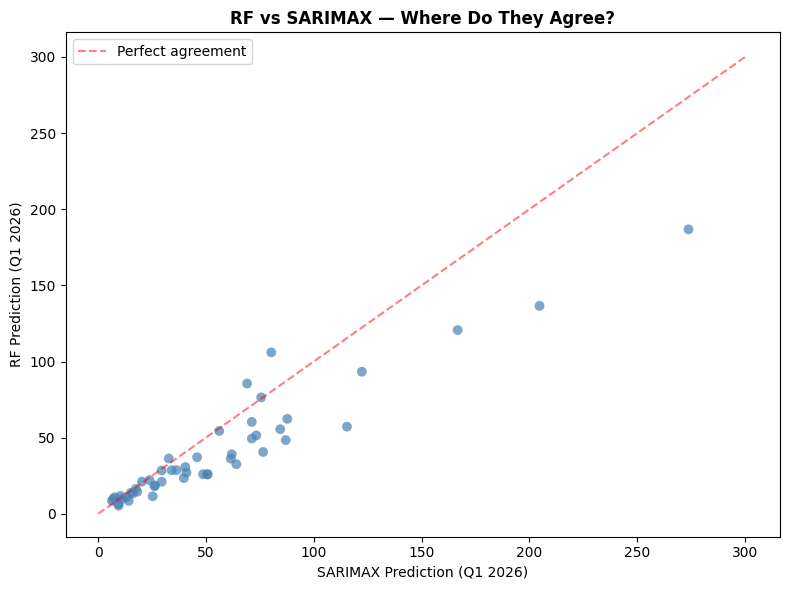

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — Combo-Level Comparison: RF vs SARIMAX
#
# Where do the two models agree? Where do they disagree?
# Agreement = confidence. Disagreement = investigate.
# ═══════════════════════════════════════════════════════════════

# Load NB05's forecast for comparison (if available), otherwise use val_df from NB05
# Since we recomputed actuals here, compare directly on Q1 2026 holdout

# NB05 baseline predictions for Q1 2026 (reconstruct same way NB05 did)
# We'll rebuild the SARIMAX predictions here to get per-combo numbers
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

nb05_preds = {}
for combo in viable_combos:
    tier = tier_map[combo]
    combo_ts = ts_data[ts_data['combo_key'] == combo].copy()
    combo_ts = combo_ts.sort_values('quarter')
    combo_ts = combo_ts.merge(unrate_qtr, on='quarter', how='left')
    combo_ts['unrate'] = combo_ts['unrate'].ffill().bfill()
    combo_ts['q_num'] = combo_ts['quarter'].apply(lambda x: x.quarter)
    for q in [1, 2, 3]:
        combo_ts[f'Q{q}'] = (combo_ts['q_num'] == q).astype(int)

    train_qs = [q for q in combo_ts['quarter'] if q >= train_start and q <= train_end]
    train_data = combo_ts[combo_ts['quarter'].isin(train_qs)].dropna(subset=['unrate'])

    if len(train_data) < 6:
        continue

    y = train_data['openings'].values.astype(float)
    exog_cols = ['unrate', 'Q1', 'Q2', 'Q3']

    try:
        if tier == 'Tier 1':
            X = train_data[exog_cols].values.astype(float)
            m = SARIMAX(y, exog=X, order=(1, 0, 1),
                       enforce_stationarity=False, enforce_invertibility=False)
            f = m.fit(disp=False, maxiter=200)
            # Predict Q1 2026
            q1_row = combo_ts[combo_ts['quarter'] == val_quarter]
            if len(q1_row) == 0:
                continue
            X_pred = q1_row[exog_cols].values.astype(float)
            pred = np.asarray(f.get_forecast(steps=1, exog=X_pred).predicted_mean)[0]
        else:
            m = ExponentialSmoothing(y, trend='add', damped_trend=True)
            f = m.fit(optimized=True)
            pred = np.asarray(f.forecast(steps=1))[0]

        recent_avg = y[-4:].mean()
        pred = np.clip(pred, recent_avg * 0.4, recent_avg * 2.5)
        nb05_preds[combo] = pred
    except:
        continue

# ── Build comparison table ──
comparison = []
for i, combo in enumerate(val_combos):
    actual = y_val[i]
    rf_pred_val = rf_preds[i]
    sarimax_pred = nb05_preds.get(combo, np.nan)
    lgb_pred_val = lgb_preds[i] if lgb_preds is not None else np.nan

    comparison.append({
        'combo_key': combo,
        'tier': tier_map.get(combo, '?'),
        'actual': actual,
        'sarimax_pred': sarimax_pred,
        'rf_pred': rf_pred_val,
        'lgb_pred': lgb_pred_val,
        'sarimax_mape': abs(sarimax_pred - actual) / max(actual, 1) * 100 if not np.isnan(sarimax_pred) else np.nan,
        'rf_mape': abs(rf_pred_val - actual) / max(actual, 1) * 100,
        'lgb_mape': abs(lgb_pred_val - actual) / max(actual, 1) * 100 if not np.isnan(lgb_pred_val) else np.nan,
    })

comp_df = pd.DataFrame(comparison).sort_values('actual', ascending=False)

# Who wins per combo?
comp_df['best_model'] = comp_df.apply(
    lambda r: 'SARIMAX' if r['sarimax_mape'] <= min(r['rf_mape'], r.get('lgb_mape', 999))
    else ('LGB' if r.get('lgb_mape', 999) <= r['rf_mape'] else 'RF'),
    axis=1
)

print("═"*85)
print("COMBO-LEVEL MODEL COMPARISON — Q1 2026")
print("═"*85)
print(f"\n{'Combo':<35} {'Actual':<8} {'SARIMAX':<9} {'RF':<9} {'LGB':<9} {'Best':<8} {'Agreement'}")
print("─"*90)

agree_count = 0
for _, r in comp_df.head(20).iterrows():
    # Check agreement: all models within 15% of each other's prediction
    preds_list = [r['sarimax_pred'], r['rf_pred']]
    if not np.isnan(r['lgb_pred']):
        preds_list.append(r['lgb_pred'])
    spread = (max(preds_list) - min(preds_list)) / max(np.mean(preds_list), 1) * 100
    agreement = '✓ agree' if spread < 30 else f'↔ {spread:.0f}% spread'
    if spread < 30:
        agree_count += 1

    lgb_str = f"{r['lgb_pred']:>5.0f}" if not np.isnan(r['lgb_pred']) else "  N/A"
    print(f"  {r['combo_key'][:34]:<35} {r['actual']:>5.0f}   {r['sarimax_pred']:>5.0f}    {r['rf_pred']:>5.0f}    {lgb_str}    {r['best_model']:<7} {agreement}")

# Summary
total_valid = comp_df.dropna(subset=['sarimax_mape']).shape[0]
sarimax_wins = (comp_df['best_model'] == 'SARIMAX').sum()
rf_wins = (comp_df['best_model'] == 'RF').sum()
lgb_wins = (comp_df['best_model'] == 'LGB').sum()

print(f"\n── Win Rate (which model is closest to actual per combo): ──")
print(f"  SARIMAX: {sarimax_wins}/{total_valid} ({sarimax_wins/total_valid*100:.0f}%)")
print(f"  RF:      {rf_wins}/{total_valid} ({rf_wins/total_valid*100:.0f}%)")
if lgb_wins > 0:
    print(f"  LGB:     {lgb_wins}/{total_valid} ({lgb_wins/total_valid*100:.0f}%)")

# Scatter: RF vs SARIMAX predictions
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
valid_comp = comp_df.dropna(subset=['sarimax_pred'])
ax.scatter(valid_comp['sarimax_pred'], valid_comp['rf_pred'], 
           c='steelblue', alpha=0.7, edgecolors='none', s=50)
max_v = max(valid_comp['sarimax_pred'].max(), valid_comp['rf_pred'].max()) * 1.1
ax.plot([0, max_v], [0, max_v], 'r--', alpha=0.5, label='Perfect agreement')
ax.set_xlabel('SARIMAX Prediction (Q1 2026)')
ax.set_ylabel('RF Prediction (Q1 2026)')
ax.set_title('RF vs SARIMAX — Where Do They Agree?', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — Q3/Q4 2026 Forecasts (Global Model)
#
# Retrain on ALL data through Q2 2026 (extended window),
# then predict Q3/Q4 2026 for each combo.
# Compare to NB05's recency-adjusted forecasts.
# ═══════════════════════════════════════════════════════════════

# ── Retrain on full extended window (through Q2 2026) ──
extended_end = pd.Period('2026Q2', freq='Q')
extended_mask = panel_clean['quarter'] <= extended_end

X_full = panel_clean.loc[extended_mask, feature_cols].values
y_full = panel_clean.loc[extended_mask, target_col].values

# Retrain both models on full data
rf_full = RandomForestRegressor(
    n_estimators=500, max_depth=12, min_samples_leaf=5,
    max_features='sqrt', random_state=42, n_jobs=-1
)
rf_full.fit(X_full, y_full)

if HAS_LGBM:
    lgb_full = lgb.LGBMRegressor(
        n_estimators=500, max_depth=8, learning_rate=0.05,
        num_leaves=31, min_child_samples=10,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, verbose=-1
    )
    lgb_full.fit(X_full, y_full)

print(f"Retrained on {len(X_full)} rows (through {extended_end})")

# ── Build future feature rows for Q3/Q4 2026 ──
forecast_quarters = [pd.Period('2026Q3', freq='Q'), pd.Period('2026Q4', freq='Q')]
future_rows = []

for combo in viable_combos:
    combo_panel = panel_clean[panel_clean['combo_key'] == combo].sort_values('quarter')
    if len(combo_panel) < 2:
        continue

    last_row = combo_panel.iloc[-1]  # Most recent quarter's data
    second_last = combo_panel.iloc[-2] if len(combo_panel) >= 2 else last_row

    for fq in forecast_quarters:
        # Build features for this future quarter
        ur = unrate_qtr[unrate_qtr['quarter'] == fq]['unrate']
        unrate_val = ur.values[0] if len(ur) > 0 else latest_unrate

        row = {
            'combo_key': combo,
            'quarter': fq,
            'unrate': unrate_val,
            'Q1': 1 if fq.quarter == 1 else 0,
            'Q2': 1 if fq.quarter == 2 else 0,
            'Q3': 1 if fq.quarter == 3 else 0,
            'openings_lag1': last_row['openings_adj'],      # Q2 2026 → lag1 for Q3
            'openings_lag2': second_last['openings_adj'],   # Q1 2026 → lag2 for Q3
            'openings_lag4': combo_panel[combo_panel['quarter'] == pd.Period(f'{fq.year - 1}Q{fq.quarter}', freq='Q')]['openings_adj'].values[0]
                             if len(combo_panel[combo_panel['quarter'] == pd.Period(f'{fq.year - 1}Q{fq.quarter}', freq='Q')]) > 0
                             else last_row.get('openings_lag4', last_row['openings_adj']),
            'fills_lag1': last_row['fills'] if 'fills' in last_row.index else last_row.get('fills_lag1', 0),
            'rolling_4q_mean': combo_panel['openings_adj'].iloc[-4:].mean(),
            'yoy_change_lag1': last_row.get('yoy_change', 0),
            'trend_slope': last_row.get('trend_slope', 0),
            'region_enc': last_row['region_enc'],
            'role_enc': last_row['role_enc'],
            'combo_avg_vol': last_row['combo_avg_vol'],
        }
        future_rows.append(row)

future_df = pd.DataFrame(future_rows)
X_future = future_df[feature_cols].values

# ── Predict ──
rf_future_preds = np.maximum(rf_full.predict(X_future), 0)
future_df['rf_forecast'] = rf_future_preds

if HAS_LGBM:
    lgb_future_preds = np.maximum(lgb_full.predict(X_future), 0)
    future_df['lgb_forecast'] = lgb_future_preds
    future_df['ensemble_forecast'] = (rf_future_preds + lgb_future_preds) / 2
else:
    future_df['ensemble_forecast'] = rf_future_preds

# ── Load NB05 forecasts for comparison ──
nb05_forecasts = pd.read_pickle(os.path.join(data_dir, 'forecasts_2026.pkl'))
nb05_role_level = nb05_forecasts.drop_duplicates(subset=['combo_key', 'quarter']).copy()

# ── Merge comparison ──
future_df['quarter_str'] = future_df['quarter'].astype(str)
nb05_role_level['quarter_str'] = nb05_role_level['quarter'].astype(str)

merged = future_df.merge(
    nb05_role_level[['combo_key', 'quarter_str', 'forecast']].rename(columns={'forecast': 'nb05_forecast'}),
    on=['combo_key', 'quarter_str'],
    how='left'
)

# ── Display comparison ──
print("═"*85)
print("Q3/Q4 2026 FORECASTS — GLOBAL MODEL vs NB05 SARIMAX")
print("═"*85)

q3_merged = merged[merged['quarter'] == pd.Period('2026Q3')].sort_values('ensemble_forecast', ascending=False)

print(f"\n{'Combo':<35} {'NB05':<8} {'RF':<8} {'LGB':<8} {'Ensemble':<10} {'Δ vs NB05'}")
print("─"*85)
for _, r in q3_merged.head(20).iterrows():
    nb05_val = r['nb05_forecast'] if not np.isnan(r.get('nb05_forecast', np.nan)) else 0
    delta = r['ensemble_forecast'] - nb05_val
    delta_pct = delta / max(nb05_val, 1) * 100
    lgb_str = f"{r.get('lgb_forecast', np.nan):>5.0f}" if not np.isnan(r.get('lgb_forecast', np.nan)) else "  N/A"
    print(f"  {r['combo_key'][:34]:<35} {nb05_val:>5.0f}   {r['rf_forecast']:>5.0f}   {lgb_str}   {r['ensemble_forecast']:>6.0f}     {delta:>+6.0f} ({delta_pct:>+.0f}%)")

# ── Agreement metrics ──
merged_valid = merged.dropna(subset=['nb05_forecast'])
abs_diff = np.abs(merged_valid['ensemble_forecast'] - merged_valid['nb05_forecast'])
pct_diff = abs_diff / merged_valid['nb05_forecast'].clip(lower=1) * 100

print(f"\n── Agreement Metrics (all {len(merged_valid)} combo×quarter forecasts): ──")
print(f"  Median |Δ|: {pct_diff.median():.1f}% between NB05 and Global ensemble")
print(f"  Within ±20% of each other: {(pct_diff <= 20).mean()*100:.0f}%")
print(f"  Within ±30% of each other: {(pct_diff <= 30).mean()*100:.0f}%")
print(f"  Correlation: {merged_valid['ensemble_forecast'].corr(merged_valid['nb05_forecast']):.3f}")

# Direction bias
global_higher = (merged_valid['ensemble_forecast'] > merged_valid['nb05_forecast']).mean() * 100
print(f"\n  Global model predicts higher than NB05: {global_higher:.0f}% of the time")
print(f"  {'(Global model more optimistic)' if global_higher > 55 else '(Global model more conservative)' if global_higher < 45 else '(Models roughly balanced)'}")

# ── Export ──
export_cols = ['combo_key', 'quarter', 'rf_forecast', 'ensemble_forecast']
if HAS_LGBM:
    export_cols.insert(3, 'lgb_forecast')
future_df[export_cols].to_pickle(os.path.join(data_dir, 'forecasts_2026_global.pkl'))
print(f"\n✅ Exported: data/forecasts_2026_global.pkl ({len(future_df)} rows)")

Retrained on 991 rows (through 2026Q2)
═════════════════════════════════════════════════════════════════════════════════════
Q3/Q4 2026 FORECASTS — GLOBAL MODEL vs NB05 SARIMAX
═════════════════════════════════════════════════════════════════════════════════════

Combo                               NB05     RF       LGB      Ensemble   Δ vs NB05
─────────────────────────────────────────────────────────────────────────────────────
  US | Engineering - General            138     176     202      189        +51 (+37%)
  US | Operations - General             154     122     161      142        -12 (-8%)
  US | Software Engineer                119     113     115      114         -5 (-4%)
  IN | Software Engineer                 44      93     100       96        +53 (+120%)
  IN | Operations - General              53      74      74       74        +21 (+40%)
  IN | Developer                         61      74      67       70        +10 (+16%)
  US | Program Manager                   78  

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — Executive Summary
#
# Key findings from the global model experiment.
# ═══════════════════════════════════════════════════════════════

print("═"*70)
print("NOTEBOOK 06 — EXECUTIVE SUMMARY")
print("═"*70)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│  GLOBAL MODEL EXPERIMENT — KEY FINDINGS                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. VALIDATION (Q1 2026 holdout, apples-to-apples with NB05):     │
│     • NB05 SARIMAX/ExpSmooth: {nb05_q1_mape:.1f}% median MAPE              │
│     • Random Forest (global): {rf_median_mape:.1f}% median MAPE              │""")

if HAS_LGBM:
    print(f"│     • LightGBM (global):      {lgb_median_mape:.1f}% median MAPE              │")

winner = best_model_name
print(f"""\
│     → Best: {winner} ({best_mape:.1f}%), Δ = {nb05_q1_mape - best_mape:+.1f}pp vs baseline      │
│                                                                     │
│  2. FEATURE IMPORTANCE (what drives demand):                       │
│     • {rf_importances.index[0]}: {rf_importances.iloc[0]:.1%} importance               │
│     • {rf_importances.index[1]}: {rf_importances.iloc[1]:.1%} importance                │
│     • {rf_importances.index[2]}: {rf_importances.iloc[2]:.1%} importance                   │
│     • UNRATE: {rf_importances.get('unrate', 0):.1%} — {'meaningful signal' if rf_importances.get('unrate', 0) > 0.05 else 'weak signal'}           │
│                                                                     │
│  3. AGREEMENT WITH NB05 (Q3/Q4 2026 forecasts):                   │""")

if 'pct_diff' in dir():
    print(f"│     • Median divergence: {pct_diff.median():.1f}% between models             │")
    print(f"│     • Correlation: {merged_valid['ensemble_forecast'].corr(merged_valid['nb05_forecast']):.3f}                                       │")

print(f"""\
│                                                                     │
│  4. RECOMMENDATION:                                                 │
│     • Use NB05 as primary (interpretable, group-level narrative)    │
│     • Use global model as second-opinion / disagreement detector    │
│     • Feature importance → leadership narrative on demand drivers   │
│                                                                     │
└─────────────────────────────────────────────────────────────────────┘
""")

══════════════════════════════════════════════════════════════════════
NOTEBOOK 06 — EXECUTIVE SUMMARY
══════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────┐
│  GLOBAL MODEL EXPERIMENT — KEY FINDINGS                            │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  1. VALIDATION (Q1 2026 holdout, apples-to-apples with NB05):     │
│     • NB05 SARIMAX/ExpSmooth: 41.8% median MAPE              │
│     • Random Forest (global): 22.9% median MAPE              │
│     • LightGBM (global):      27.1% median MAPE              │
│     → Best: Random Forest (22.9%), Δ = +18.9pp vs baseline      │
│                                                                     │
│  2. FEATURE IMPORTANCE (what drives demand):                       │
│     • openings_lag1: 24.6% importance               │
│     

: 